In [26]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

In [42]:
# Load CSV files
train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

print(train_data.shape)
print(test_data.shape)

(60000, 785)
(10000, 785)


In [ ]:
# Separate Features and Labels

X = train_data.drop("label", axis=1).values.astype('float32')
y = train_data["label"].values.astype('int32')

X_test = test_data.drop("label", axis=1).values.astype('float32')
y_test = test_data["label"].values.astype('int32')

In [29]:
# Reshape into 28x28x1
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [30]:
# Scale pixel values between 0 and 1
X = X / 255.0
X_test = X_test / 255.0

In [31]:
# One-hot encoding
y = to_categorical(y, 10)
y_test = to_categorical(y_test, 10)


In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(48000, 28, 28, 1)
(12000, 28, 28, 1)


In [33]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

# Second Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.7678 - loss: 0.6438 - val_accuracy: 0.8580 - val_loss: 0.3839
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.8484 - loss: 0.4229 - val_accuracy: 0.8633 - val_loss: 0.3591
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 63ms/step - accuracy: 0.8692 - loss: 0.3667 - val_accuracy: 0.8927 - val_loss: 0.2914
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.8812 - loss: 0.3319 - val_accuracy: 0.8898 - val_loss: 0.2934
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.8907 - loss: 0.3051 - val_accuracy: 0.8953 - val_loss: 0.2913
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.8957 - loss: 0.2862 - val_accuracy: 0.8964 - val_loss: 0.2764
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9032 - loss: 0.2702 - val_accuracy: 0.9049 - val_loss: 0.2531
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.9075 - loss: 0.2542 - 

In [37]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9136 - loss: 0.2326
Test Accuracy: 0.9136000275611877


In [38]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

actual_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [39]:
fashion_labels = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

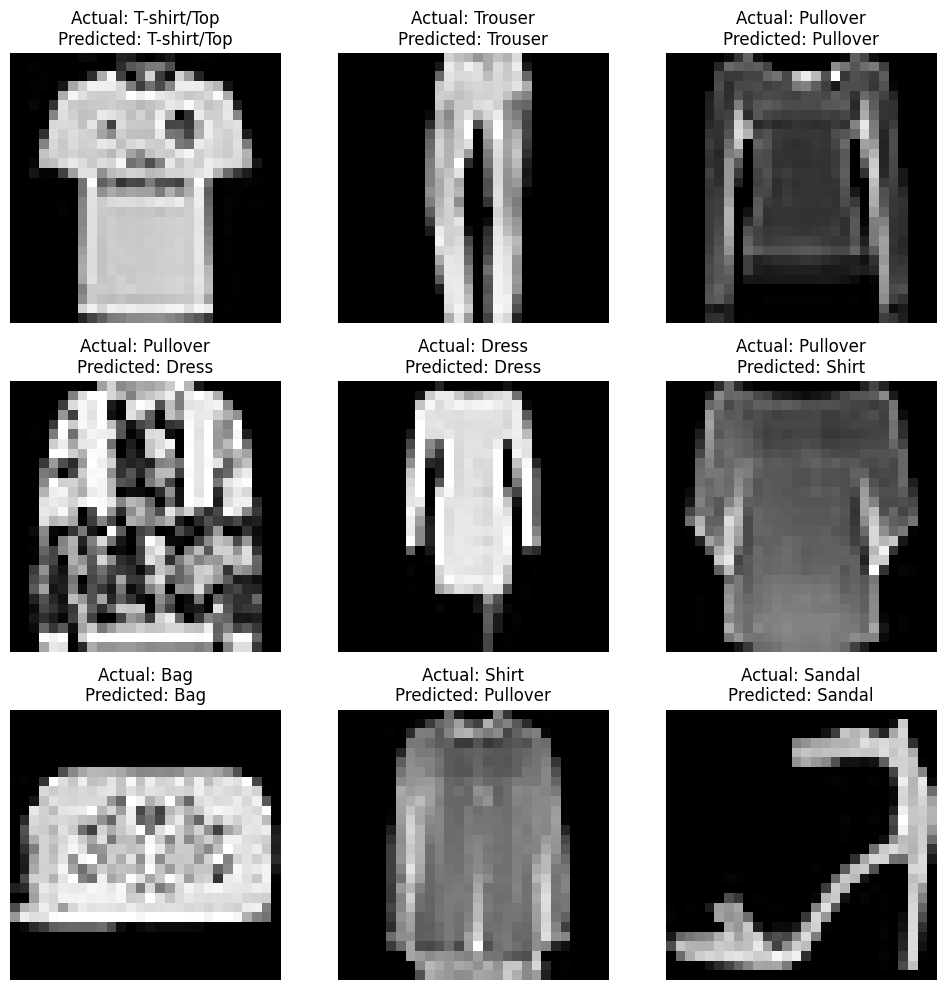

In [40]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Actual: {fashion_labels[actual_classes[i]]}\n"
        f"Predicted: {fashion_labels[predicted_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()